In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
 
from src.classifier.model import (
    load_matrix, train, evaluate, save, split_xy,
    feature_columns, SUPERCLASSES,
)


In [3]:
df = load_matrix()
models, thresholds, feat_cols = train(df)

Features: 110  |  train=17,084 val=2,146 test=2,158
  trained NORM  (pos_weight= 1.25, thresh=0.55)
  trained MI    (pos_weight= 2.90, thresh=0.45)
  trained STTC  (pos_weight= 3.08, thresh=0.45)
  trained CD    (pos_weight= 3.37, thresh=0.60)
  trained HYP   (pos_weight= 7.06, thresh=0.55)


In [4]:
val_report = evaluate(models, thresholds, feat_cols, df, split="val")
print("=== Validation (fold 9) ===")
val_report.show()
 
test_report = evaluate(models, thresholds, feat_cols, df, split="test")
print("\n=== Test (fold 10) ===")
test_report.show()

=== Validation (fold 9) ===

class    AUROC      F1    prec  recall  thresh
----------------------------------------------
NORM     0.916   0.826   0.792   0.863    0.55
MI       0.844   0.625   0.557   0.711    0.45
STTC     0.875   0.657   0.594   0.735    0.45
CD       0.861   0.692   0.753   0.640    0.60
HYP      0.886   0.586   0.583   0.590    0.55
----------------------------------------------
MACRO    0.876   0.677

=== Test (fold 10) ===

class    AUROC      F1    prec  recall  thresh
----------------------------------------------
NORM     0.900   0.800   0.767   0.835    0.55
MI       0.840   0.620   0.561   0.693    0.45
STTC     0.872   0.644   0.573   0.735    0.45
CD       0.842   0.644   0.686   0.607    0.60
HYP      0.881   0.581   0.554   0.611    0.55
----------------------------------------------
MACRO    0.867   0.658


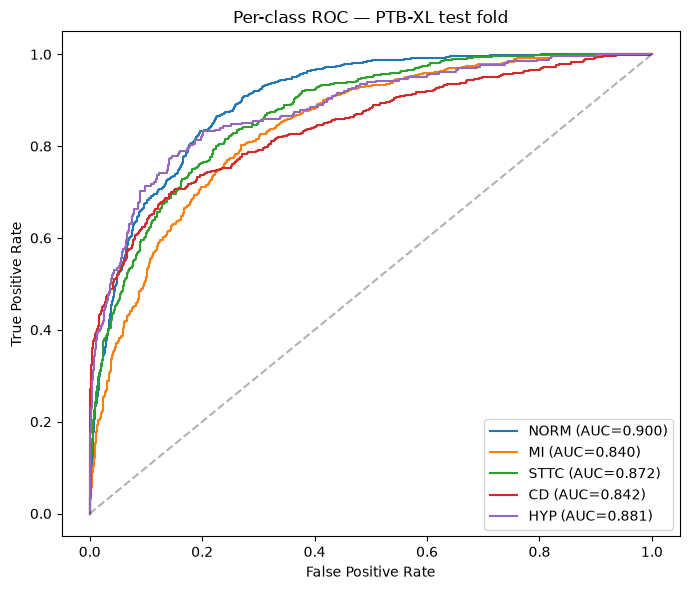

In [5]:
splits = split_xy(df, feat_cols)
X_test, Y_test = splits["test"]
 
plt.figure(figsize=(7, 6))
for i, name in enumerate(SUPERCLASSES):
    y_true = Y_test[:, i]
    y_prob = models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Per-class ROC — PTB-XL test fold"); plt.legend()
plt.tight_layout(); plt.show()

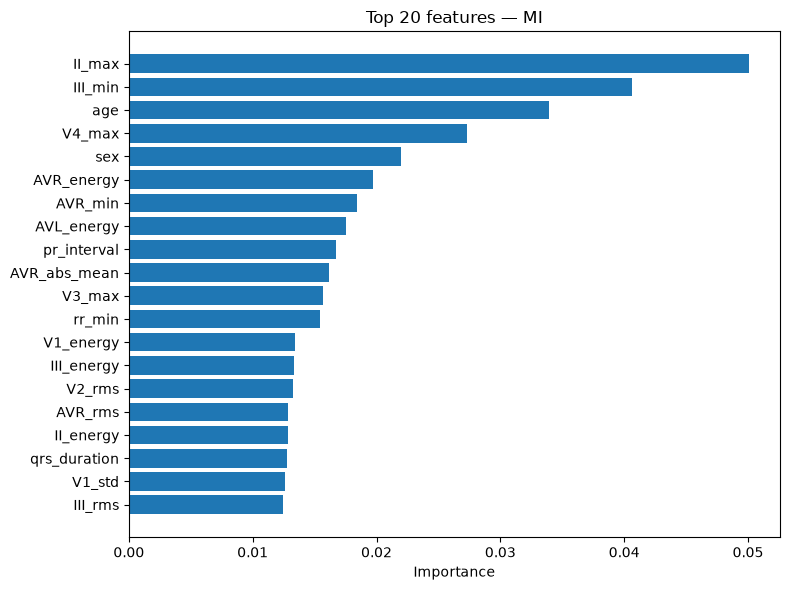

In [6]:
target = "MI"
clf = models[target]
importances = clf.feature_importances_
order = np.argsort(importances)[::-1][:20]
 
plt.figure(figsize=(8, 6))
plt.barh([feat_cols[i] for i in order][::-1],
         [importances[i] for i in order][::-1])
plt.xlabel("Importance"); plt.title(f"Top 20 features — {target}")
plt.tight_layout(); plt.show()

In [ ]:
save(models, thresholds, feat_cols)